In [3]:
import json
import pandas as pd

# === 1. Đọc file JSON ===
with open("job_7863381_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# === 2. Ánh xạ timeSet → tên khung giờ ===
time_set_map = {ts["@id"]: ts["name"] for ts in data.get("timeSets", [])}

rows = []

# === 3. Duyệt các segment trong network ===
for seg in data.get("network", {}).get("segmentResults", []):
    segment_time_results = seg.get("segmentTimeResults", [])
    shape_coords = seg.get("shape", [])

    # Chuyển shape sang chuỗi toạ độ
    coords_str = "; ".join(
        [f"({pt['latitude']}, {pt['longitude']})" for pt in shape_coords]
    )

    # Lặp qua từng timeSet
    for result in segment_time_results:
        percentiles = result.get("speedPercentiles", [])
        percentiles_str = ",".join(map(str, percentiles)) if percentiles else ""

        row = {
            "segmentId": seg.get("segmentId"),
            "newSegmentId": seg.get("newSegmentId"),
            "streetName": seg.get("streetName"),
            "speedLimit": seg.get("speedLimit"),
            "frc": seg.get("frc"),
            "distance": seg.get("distance"),
            "timeSet": result.get("timeSet"),
            "timeSetName": time_set_map.get(result.get("timeSet"), "Unknown"),
            "dateRange": result.get("dateRange"),
            "harmonicAverageSpeed": result.get("harmonicAverageSpeed"),
            "medianSpeed": result.get("medianSpeed"),
            "averageSpeed": result.get("averageSpeed"),
            "standardDeviationSpeed": result.get("standardDeviationSpeed"),
            "travelTimeStandardDeviation": result.get("travelTimeStandardDeviation"),
            "sampleSize": result.get("sampleSize"),
            "averageTravelTime": result.get("averageTravelTime"),
            "medianTravelTime": result.get("medianTravelTime"),
            "travelTimeRatio": result.get("travelTimeRatio"),
            "speedPercentiles": percentiles_str,
            "coordinates": coords_str,
        }
        rows.append(row)

# === 4. Tạo DataFrame và xuất CSV ===
df = pd.DataFrame(rows)
output_file = "thu_duc_segment_results.csv"
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"✅ Đã tạo file CSV từ JSON mới: {output_file}")

PermissionError: [Errno 13] Permission denied: 'thu_duc_segment_results.csv'

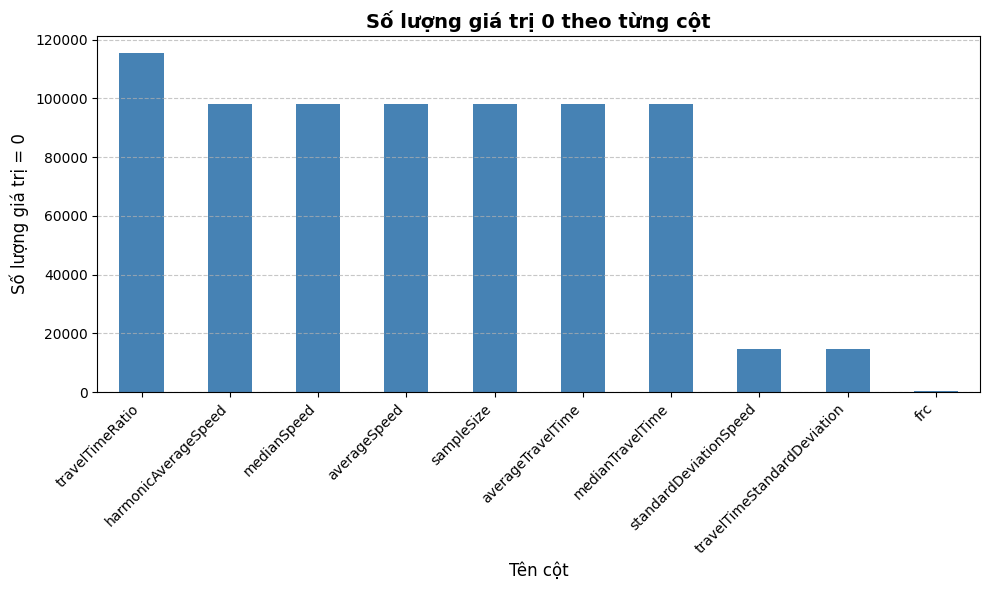

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Đọc file CSV ===
df = pd.read_csv("thu_duc_segment_results.csv", encoding="utf-8-sig")

# === 2. Đếm giá trị 0 ===
zero_counts = (df == 0).sum()
zero_counts = zero_counts[zero_counts > 0]  # chỉ giữ cột có ít nhất 1 giá trị 0

# === 3. Kiểm tra và vẽ ===
if zero_counts.empty:
    print("⚠️ Không có giá trị 0 nào trong DataFrame — không thể vẽ biểu đồ.")
else:
    plt.figure(figsize=(10, 6))
    zero_counts.sort_values(ascending=False).plot(kind="bar", color="steelblue")

    plt.title("Số lượng giá trị 0 theo từng cột", fontsize=14, fontweight="bold")
    plt.xlabel("Tên cột", fontsize=12)
    plt.ylabel("Số lượng giá trị = 0", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()